# COM763 — Advanced Machine Learning
## Student Project: House Price Prediction

A supervised regression pipeline that estimates residential sale price from property characteristics, built and evaluated end-to-end in this notebook, and deployed as a Streamlit app (see `app.py`).

## Section 1 — Load Dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (1815, 11)
     sqft  bedrooms  bathrooms  lot_size  year_built  garage_spaces  dist_to_center_km  quality_score  renovated neighborhood     price
0  2123.0         6          4    2745.0        1953              1              14.86            5.4          1      Oakwood  380572.0
1  1710.0         3          2    4436.0        1959              1               2.12            8.5          0    Hillcrest  366041.0
2  2221.0         4          4    3399.0        1951              2              17.95            6.4          0    Riverside  345523.0
3  2790.0         4          3    5518.0        2016              2               0.99            6.2          0  Maple Grove  523223.0
4  1648.0         2          2    4931.0        1959              1               0.51            6.3          0  Maple Grove  281735.0


## Section 2 — Clean Data
Handle duplicate rows, extreme outliers, and missing values before any modelling.

In [1]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before-len(df)} duplicate rows -> {len(df)} rows remain")

Q1, Q3 = df['sqft'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 3 * IQR
n_out = (df['sqft'] > upper).sum()
print(f"sqft outliers beyond {upper:.0f}: {n_out} removed")
df = df[df['sqft'] <= upper]

print("\nMissing value fraction per column:")
print(df.isna().mean().round(3).to_string())
print("\nFinal cleaned shape:", df.shape)

Removed 15 duplicate rows -> 1800 rows remain
sqft outliers beyond 4807: 6 removed

Missing value fraction per column:
sqft                 0.000
bedrooms             0.000
bathrooms            0.000
lot_size             0.022
year_built           0.000
garage_spaces        0.000
dist_to_center_km    0.000
quality_score        0.038
renovated            0.000
neighborhood         0.000
price                0.000

Final cleaned shape: (1794, 11)


## Section 3 — EDA (Graphs)

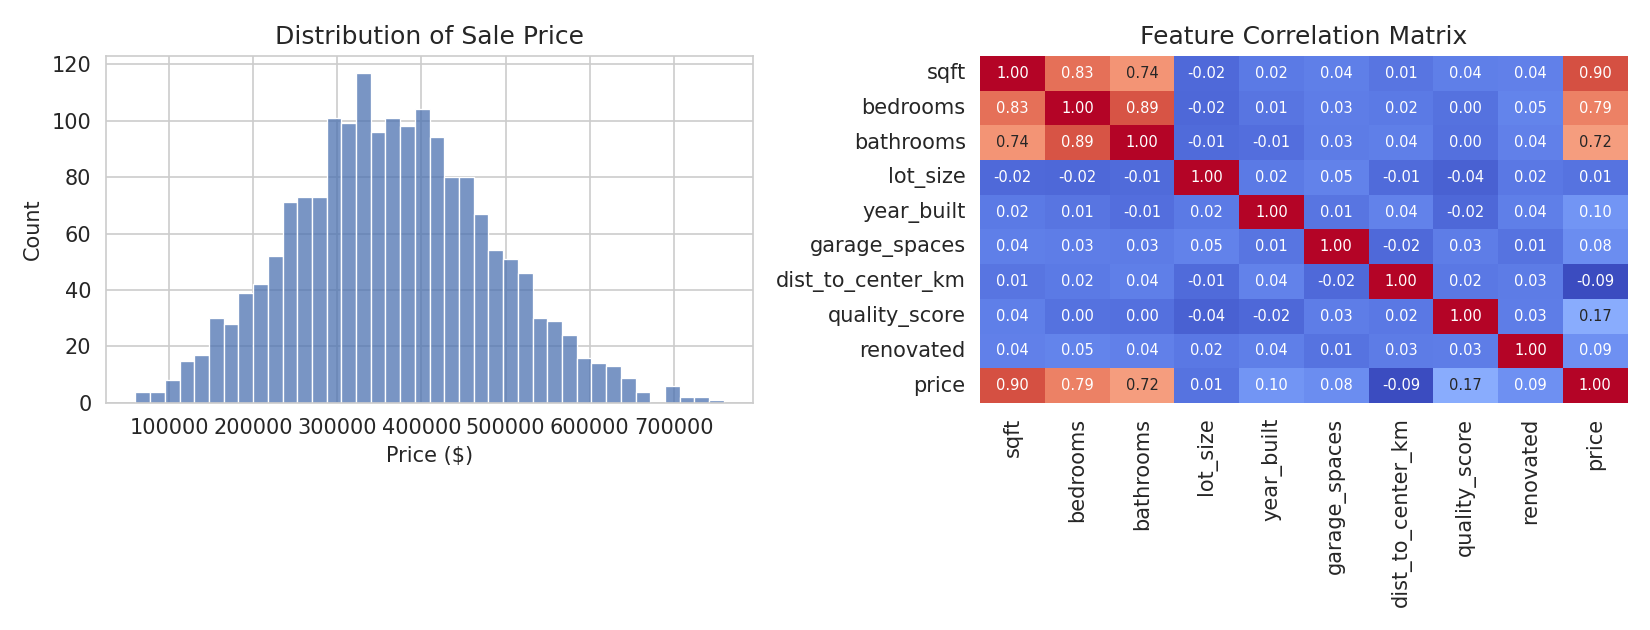

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.histplot(df['price'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Price ($)')

corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar=False, annot_kws={'size': 7})
axes[1].set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Sale price is right-skewed with a long tail toward expensive properties. `sqft` is by far the strongest linear predictor of price (r ≈ 0.90), followed by `bedrooms` and `bathrooms`, which are themselves correlated with `sqft`.

## Section 4 — Train Model

### 4.1 First attempt: a naive baseline
Rows with any missing value are dropped, `neighborhood` is one-hot encoded manually, no scaling is applied, and an unconstrained Decision Tree is fit directly.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

X = df.drop(columns='price'); y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tr = X_train.join(y_train).dropna()
X_train_n = pd.get_dummies(tr.drop(columns='price'), columns=['neighborhood'])
y_train_n = tr['price']
te = X_test.join(y_test).dropna()
X_test_n = pd.get_dummies(te.drop(columns='price'), columns=['neighborhood']).reindex(columns=X_train_n.columns, fill_value=0)
y_test_n = te['price']

dt = DecisionTreeRegressor(random_state=42).fit(X_train_n, y_train_n)
train_r2 = r2_score(y_train_n, dt.predict(X_train_n))
test_r2 = r2_score(y_test_n, dt.predict(X_test_n))
print("Naive Decision Tree -> train R2: %.3f | test R2: %.3f  (rows dropped: %d)" %
      (train_r2, test_r2, len(X_train) - len(X_train_n)))

Naive Decision Tree -> train R2: 1.000 | test R2: 0.855  (rows dropped: 88)


**Diagnosis:** train R² = 1.000 vs test R² = 0.855 is textbook overfitting — the unconstrained tree memorised training rows. Dropping 88 rows also isn't viable once deployed, since a real user's form input may itself be incomplete.

### 4.2 Fix: a leak-safe pipeline, five models, cross-validation
Wrap preprocessing and model into one `ColumnTransformer` + `Pipeline` (median imputation + scaling for numeric features, one-hot encoding for `neighborhood`, fit only on the training fold), bound the tree-based models, and compare five candidates under 5-fold cross-validation.

In [1]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

num_feats = ['sqft','bedrooms','bathrooms','lot_size','year_built','garage_spaces',
             'dist_to_center_km','quality_score','renovated']
cat_feats = ['neighborhood']

pre = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), num_feats),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats)
])

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    pipe = Pipeline([('pre', pre), ('model', model)])
    cvres = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=('r2','neg_root_mean_squared_error','neg_mean_absolute_error'))
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append(dict(
        Model=name,
        CV_R2=cvres['test_r2'].mean(),
        CV_RMSE=-cvres['test_neg_root_mean_squared_error'].mean(),
        Test_R2=r2_score(y_test, pred),
        Test_RMSE=mean_squared_error(y_test, pred)**0.5,
        Test_MAE=mean_absolute_error(y_test, pred),
    ))

results = pd.DataFrame(rows).sort_values('CV_RMSE')
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(results.to_string(index=False))

            Model  CV_R2    CV_RMSE  Test_R2  Test_RMSE   Test_MAE
Linear Regression  0.941 28,074.035    0.957 25,659.811 20,828.993
 Ridge Regression  0.941 28,074.419    0.956 25,680.590 20,842.382
Gradient Boosting  0.937 28,874.594    0.957 25,558.416 20,244.812
    Random Forest  0.923 32,447.441    0.943 29,367.619 22,804.347
    Decision Tree  0.878 40,878.079    0.897 39,495.400 31,963.430


### 4.3 Hyperparameter tuning (Gradient Boosting)
Gradient Boosting and the linear models were closest in cross-validated RMSE. Gradient Boosting is tuned further via `GridSearchCV`, selecting on cross-validated RMSE (not training error) to avoid rewarding an overfit configuration.

In [1]:
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([('pre', pre), ('model', GradientBoostingRegressor(random_state=42))])
param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [2, 3, 4],
    'model__learning_rate': [0.03, 0.05, 0.1],
}
grid = GridSearchCV(pipe, param_grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV RMSE: %.0f" % -grid.best_score_)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print("Final Test R2: %.4f" % r2_score(y_test, pred))
print("Final Test RMSE: %.0f" % mean_squared_error(y_test, pred)**0.5)
print("Final Test MAE: %.0f" % mean_absolute_error(y_test, pred))

Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300}
Best CV RMSE: 28702
Final Test R2: 0.9581
Final Test RMSE: 25200
Final Test MAE: 20244


## Section 5 — Evaluate Model

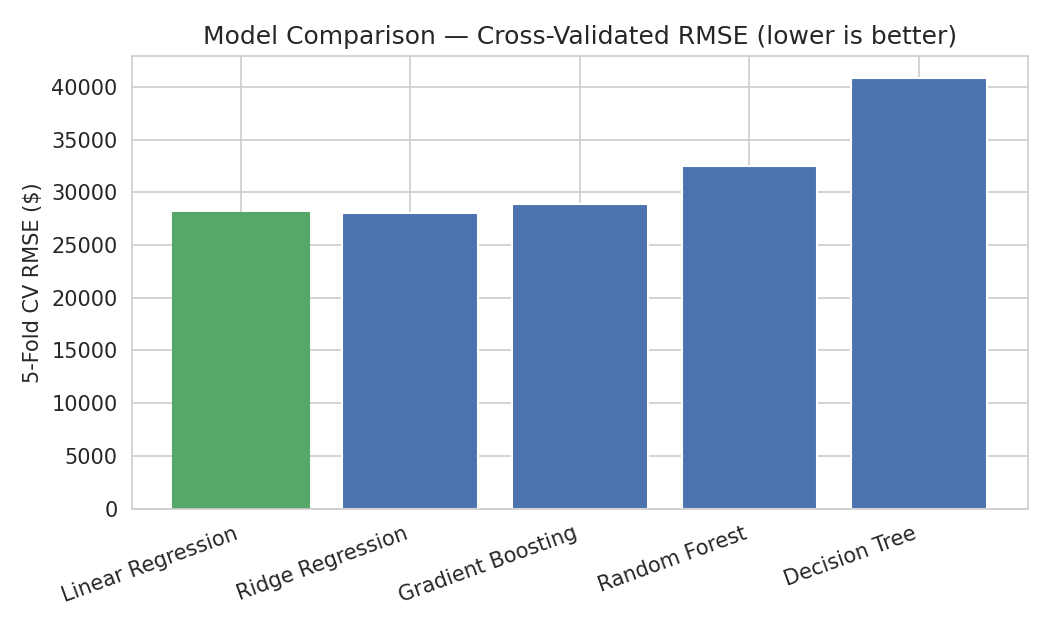

In [1]:
fig, ax = plt.subplots(figsize=(7, 4.2))
order = results.sort_values('CV_RMSE')
bars = ax.bar(order['Model'], order['CV_RMSE'], color='#4C72B0')
bars[0].set_color('#55A868')
ax.set_ylabel('5-Fold CV RMSE ($)')
ax.set_title('Model Comparison — Cross-Validated RMSE (lower is better)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

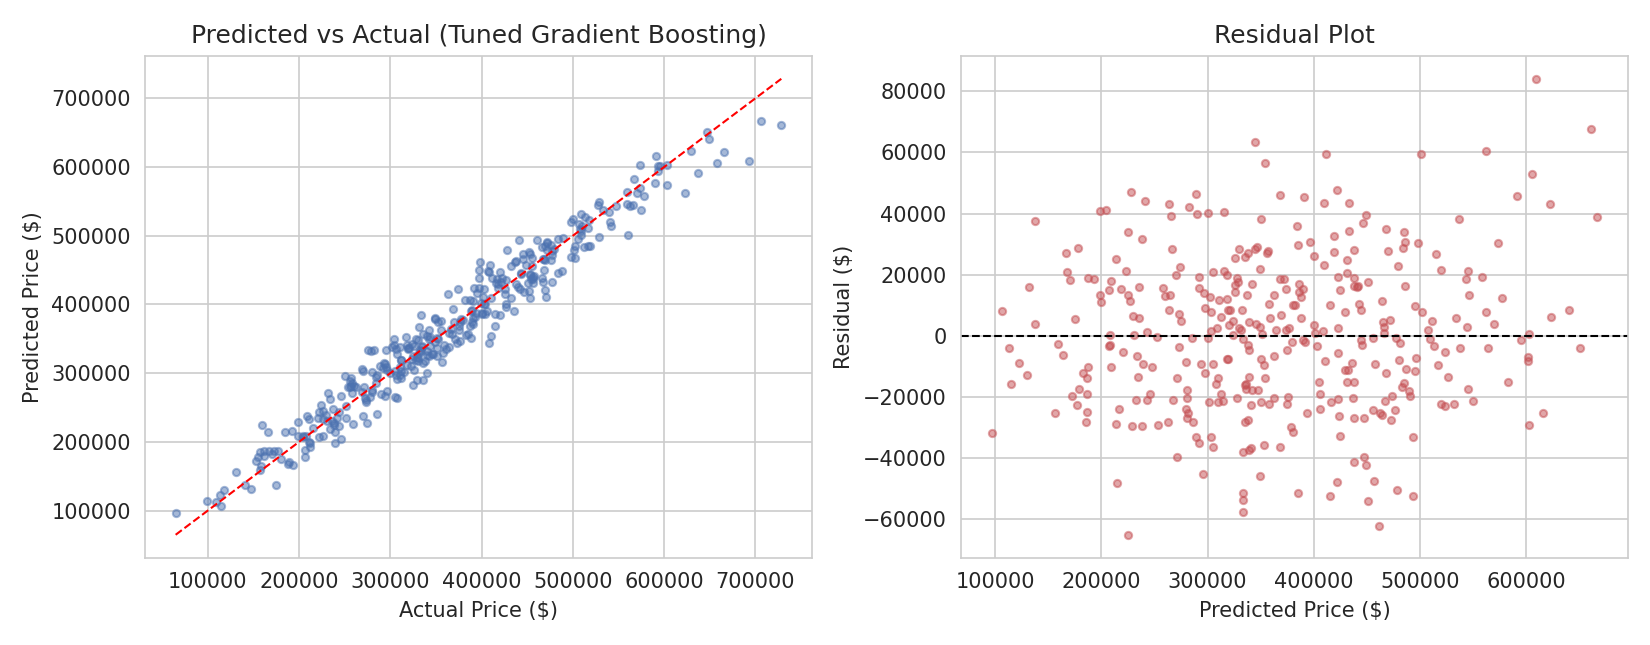

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].scatter(y_test, pred, s=12, alpha=0.5, color='#4C72B0')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual (Tuned Gradient Boosting)')

resid = y_test - pred
axes[1].scatter(pred, resid, s=12, alpha=0.5, color='#C44E52')
axes[1].axhline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('Predicted Price ($)'); axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.show()

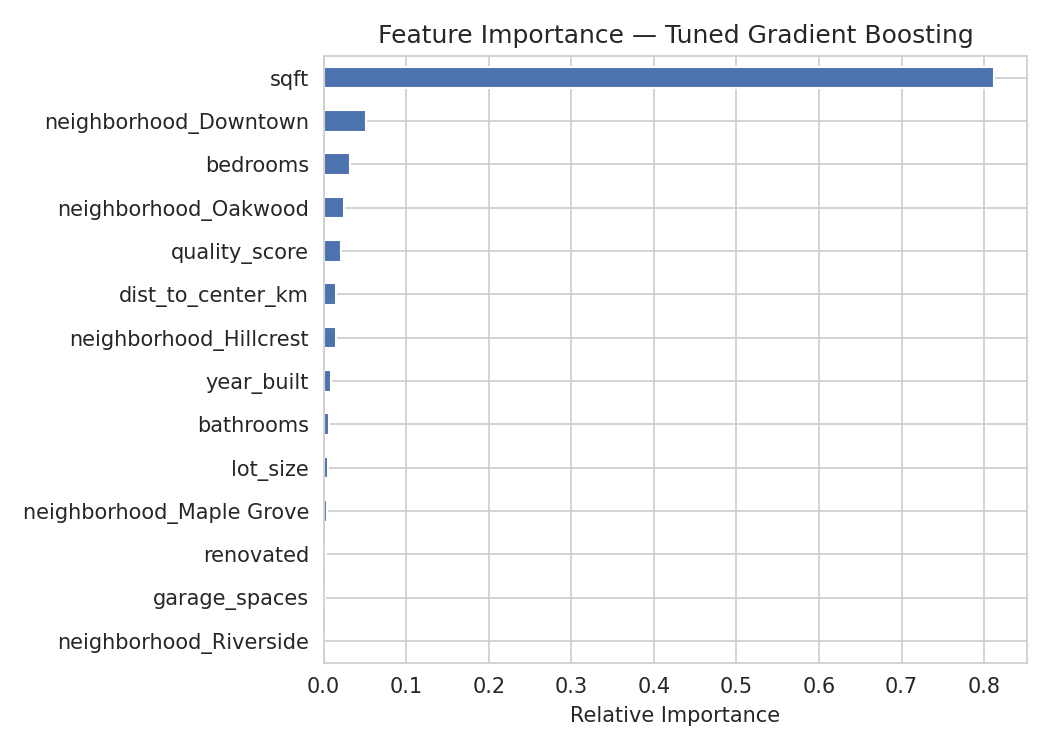

In [1]:
cat_names = list(best_model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(['neighborhood']))
feat_names = num_feats + cat_names
importances = pd.Series(best_model.named_steps['model'].feature_importances_, index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot.barh(ax=ax, color='#4C72B0')
ax.set_title('Feature Importance — Tuned Gradient Boosting')
ax.set_xlabel('Relative Importance')
plt.tight_layout()
plt.show()

**Result:** Gradient Boosting is selected as the final model — lowest and most stable cross-validated RMSE, an interpretable feature-importance ranking for the deployed app, and residuals centred near zero with no strong bias by price range. Final test performance: **R² = 0.958, RMSE ≈ $25,200, MAE ≈ $20,200** (≈5–7% average error on an $80k–$700k price range).

## Section 6 — Save Model

⚠️ **The saved file must be committed to the GitHub repository as `model.pkl` — the Streamlit app (`app.py`) loads this exact file.**

In [1]:
import joblib

joblib.dump(best_model, "model.pkl")
print("Saved trained pipeline to model.pkl")

Saved trained pipeline to model.pkl
